***

* [总目录](../0_Introduction/0_introduction.ipynb)
* [术语表](../0_Introduction/1_glossary.ipynb)
* [9. 实践部分](9_1_visualisation-inspection.ipynb)
    * 上一节： [9.11 交叉手相位校准与 RM synthesis](9_11_polarization_calibration_and_rm_synthesis.ipynb)
    * 下一节： [9.13 高级谱线分析](9_13_advanced_spectral_line_analysis.ipynb)

***


导入标准模块:


In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

try:
    from IPython.display import HTML, display
except ImportError:
    HTML = None
    display = None

STYLE_PATH = Path("../style/course.css")
TOGGLE_PATH = Path("../style/code_toggle.html")

if HTML is not None and display is not None:
    if STYLE_PATH.exists():
        display(HTML(f"<style>{STYLE_PATH.read_text(encoding='utf-8')}</style>"))
    if TOGGLE_PATH.exists():
        display(HTML(TOGGLE_PATH.read_text(encoding="utf-8")))

plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.grid"] = True
np.set_printoptions(precision=3, suppress=True)

RNG = np.random.default_rng(20260421)


## 9.12 宽场方向相关成像：`w-term`、faceting 与 PB-aware mosaic

`9.8` 已经把宽带/宽场成像的第一层逻辑建立起来了，但真实宽场处理往往还会继续遇到两类更棘手的方向相关问题：

- 非共面基线带来的 `w-term`，会让离轴源在简单二维成像里出现失真、展宽甚至位置和峰值偏差；
- 主波束随视场方向变化，多个指向或长时间覆盖的宽场数据如果不做 beam-aware 处理，就会在拼接结果里留下明显的通量偏差。

这一节不试图复刻工业级 `w-projection`、`A-projection` 或 `AW-projection` 实现，而是用两个可以直接运行的最小实验，把现代宽场方向相关成像的判断链建立起来：

- 为什么忽略 `w-term` 会让离轴源被严重压扁；
- 为什么 faceting 能在局部恢复离轴源；
- 为什么多指向拼接不能只做简单平均；
- 为什么 `PB-aware mosaic` 的通量恢复往往伴随着边缘噪声放大。


***


In [2]:
def n_term(l, m):
    return np.sqrt(np.clip(1.0 - l**2 - m**2, 1.0e-12, None))


def simulate_visibilities(u, v, w, sources, noise_std=0.0):
    vis = np.zeros(u.size, dtype=complex)
    for src in sources:
        n_src = n_term(src["l"], src["m"])
        phase = -2.0 * np.pi * (
            u * src["l"] + v * src["m"] + w * (n_src - 1.0)
        )
        vis += (src["flux"] / n_src) * np.exp(1j * phase)
    if noise_std > 0.0:
        vis += noise_std * (
            RNG.normal(size=u.size) + 1j * RNG.normal(size=u.size)
        )
    return vis


def dirty_image_from_visibilities(
    u, v, w, vis, l_grid, m_grid, use_w_term=False
):
    ll, mm = np.meshgrid(l_grid, m_grid)
    image = np.zeros_like(ll, dtype=complex)
    nn = n_term(ll, mm)
    for uk, vk, wk, vis_k in zip(u, v, w, vis):
        phase = uk * ll + vk * mm
        if use_w_term:
            phase = phase + wk * (nn - 1.0)
        image += vis_k * np.exp(2j * np.pi * phase)
    image /= u.size
    return np.real(image)


def phase_shift_visibilities(vis, u, v, w, l0, m0):
    n0 = n_term(l0, m0)
    shift = np.exp(2j * np.pi * (u * l0 + v * m0 + w * (n0 - 1.0)))
    return vis * shift


def local_peak(image, l_grid, m_grid, l0, m0, radius):
    ll, mm = np.meshgrid(l_grid, m_grid)
    mask = ((ll - l0) ** 2 + (mm - m0) ** 2) <= radius**2
    return np.max(image[mask])


def normalized_gaussian_map(x, y, x0, y0, sigma_x, sigma_y):
    profile = np.exp(
        -0.5 * (((x - x0) / sigma_x) ** 2 + ((y - y0) / sigma_y) ** 2)
    )
    profile /= profile.max()
    return profile


def primary_beam_gain_2d(x, y, x0, y0, fwhm):
    radius2 = (x - x0) ** 2 + (y - y0) ** 2
    return np.exp(-4.0 * np.log(2.0) * radius2 / (fwhm**2))


def gaussian_kernel(npix, sigma_pix):
    coords = np.arange(npix) - npix // 2
    xx, yy = np.meshgrid(coords, coords)
    kernel = np.exp(-(xx**2 + yy**2) / (2.0 * sigma_pix**2))
    kernel /= kernel.sum()
    return kernel


def fft_convolve_same(image, kernel):
    image_ft = np.fft.fft2(image)
    kernel_ft = np.fft.fft2(np.fft.ifftshift(kernel))
    return np.real(np.fft.ifft2(image_ft * kernel_ft))


# --- experiment 1: non-coplanar baselines and faceting ---
widefield_sources = [
    {"name": "center", "flux": 1.00, "l": 0.000, "m": 0.000},
    {"name": "east_arc", "flux": 0.55, "l": 0.032, "m": -0.012},
    {"name": "northwest", "flux": 0.42, "l": -0.027, "m": 0.031},
]

nvis = 420
rho = RNG.uniform(30.0, 650.0, size=nvis)
phi = RNG.uniform(0.0, 2.0 * np.pi, size=nvis)
u_coords = rho * np.cos(phi)
v_coords = rho * np.sin(phi)
w_coords = RNG.uniform(-1200.0, 1200.0, size=nvis)
vis_noise_std = 0.015

widefield_vis = simulate_visibilities(
    u_coords, v_coords, w_coords, widefield_sources, noise_std=vis_noise_std
)

full_l_grid = np.linspace(-0.055, 0.055, 72)
full_m_grid = np.linspace(-0.055, 0.055, 72)
naive_dirty = dirty_image_from_visibilities(
    u_coords, v_coords, w_coords, widefield_vis, full_l_grid, full_m_grid, use_w_term=False
)
widefield_dirty = dirty_image_from_visibilities(
    u_coords, v_coords, w_coords, widefield_vis, full_l_grid, full_m_grid, use_w_term=True
)
wterm_error_map = naive_dirty - widefield_dirty

source_east = widefield_sources[1]
facet_half_width = 0.010
facet_local_l = np.linspace(-facet_half_width, facet_half_width, 48)
facet_local_m = np.linspace(-facet_half_width, facet_half_width, 48)
shifted_vis = phase_shift_visibilities(
    widefield_vis, u_coords, v_coords, w_coords, source_east["l"], source_east["m"]
)
facet_dirty = dirty_image_from_visibilities(
    u_coords, v_coords, w_coords, shifted_vis, facet_local_l, facet_local_m, use_w_term=False
)

center_peak_naive = local_peak(naive_dirty, full_l_grid, full_m_grid, 0.0, 0.0, 0.004)
center_peak_wide = local_peak(widefield_dirty, full_l_grid, full_m_grid, 0.0, 0.0, 0.004)
east_peak_naive = local_peak(
    naive_dirty, full_l_grid, full_m_grid, source_east["l"], source_east["m"], 0.0045
)
east_peak_wide = local_peak(
    widefield_dirty, full_l_grid, full_m_grid, source_east["l"], source_east["m"], 0.0045
)
east_peak_facet = local_peak(facet_dirty, facet_local_l, facet_local_m, 0.0, 0.0, 0.003)

extent_full_deg = [
    np.rad2deg(full_l_grid[0]),
    np.rad2deg(full_l_grid[-1]),
    np.rad2deg(full_m_grid[0]),
    np.rad2deg(full_m_grid[-1]),
]
extent_facet_deg = [
    np.rad2deg(facet_local_l[0]),
    np.rad2deg(facet_local_l[-1]),
    np.rad2deg(facet_local_m[0]),
    np.rad2deg(facet_local_m[-1]),
]

# --- experiment 2: beam-aware mosaic combination ---
mosaic_npix = 96
mosaic_coords_arcmin = np.linspace(-40.0, 40.0, mosaic_npix)
x_arcmin, y_arcmin = np.meshgrid(mosaic_coords_arcmin, mosaic_coords_arcmin)

mosaic_true_sky = (
    0.80 * normalized_gaussian_map(x_arcmin, y_arcmin, -18.0, 10.0, 7.0, 5.0)
    + 1.00 * normalized_gaussian_map(x_arcmin, y_arcmin, 0.0, 0.0, 6.0, 6.0)
    + 0.55 * normalized_gaussian_map(x_arcmin, y_arcmin, 20.0, -12.0, 8.0, 4.0)
    + 0.22 * normalized_gaussian_map(x_arcmin, y_arcmin, 28.0, 22.0, 4.0, 4.0)
)

mosaic_beam = gaussian_kernel(mosaic_npix, sigma_pix=1.3)
pb_fwhm_arcmin = 36.0
pb_1 = primary_beam_gain_2d(x_arcmin, y_arcmin, -12.0, 0.0, pb_fwhm_arcmin)
pb_2 = primary_beam_gain_2d(x_arcmin, y_arcmin, 12.0, 0.0, pb_fwhm_arcmin)
mosaic_noise_std = 8.0e-4

pointing_1 = fft_convolve_same(mosaic_true_sky * pb_1, mosaic_beam)
pointing_2 = fft_convolve_same(mosaic_true_sky * pb_2, mosaic_beam)
pointing_1 += mosaic_noise_std * RNG.normal(size=(mosaic_npix, mosaic_npix))
pointing_2 += mosaic_noise_std * RNG.normal(size=(mosaic_npix, mosaic_npix))

naive_mosaic = 0.5 * (pointing_1 + pointing_2)
pb_weight_sum = pb_1**2 + pb_2**2
pb_weighted_mosaic = (
    pb_1 * pointing_1 + pb_2 * pointing_2
) / np.maximum(pb_weight_sum, 1.0e-6)

mosaic_science_mask = (x_arcmin**2 + y_arcmin**2) <= 32.0**2
outer_source_mask = ((x_arcmin - 28.0) ** 2 + (y_arcmin - 22.0) ** 2) <= 4.0**2
mosaic_mean_abs_error_naive = np.mean(
    np.abs(naive_mosaic[mosaic_science_mask] - mosaic_true_sky[mosaic_science_mask])
)
mosaic_mean_abs_error_weighted = np.mean(
    np.abs(
        pb_weighted_mosaic[mosaic_science_mask]
        - mosaic_true_sky[mosaic_science_mask]
    )
)
outer_peak_true = np.max(mosaic_true_sky[outer_source_mask])
outer_peak_naive = np.max(naive_mosaic[outer_source_mask])
outer_peak_weighted = np.max(pb_weighted_mosaic[outer_source_mask])
center_idx = np.argmin(np.abs(mosaic_coords_arcmin - 0.0))
outer_x_idx = np.argmin(np.abs(mosaic_coords_arcmin - 28.0))
outer_y_idx = np.argmin(np.abs(mosaic_coords_arcmin - 22.0))
mosaic_noise_ratio = np.sqrt(
    pb_weight_sum[center_idx, center_idx] / pb_weight_sum[outer_y_idx, outer_x_idx]
)


### 9.12.1 `w-term` 为什么会在宽场里压坏离轴源

对非共面基线来说，可见度相位里除了熟悉的 $u l + v m$ 项，还会多出和 $w$ 有关的附加项。离轴角越大，这个项越不能忽略。

下面先做一个最小实验：

- 用含有三个点源的宽场天空生成 `uvw` 可见度；
- 先按“普通二维成像”去做，完全忽略 `w-term`；
- 再用带 `w-term` 的成像公式重建同一片天空。

这样可以直接看到：中心源通常还凑合，但离轴源会在 naive 图像里被明显压暗和扭曲。


中心源峰值：忽略 w-term ≈ 0.156，宽场校正后 ≈ 0.156
东侧离轴源峰值：忽略 w-term ≈ 0.067，宽场校正后 ≈ 0.400
若忽略 w-term，东侧离轴源只恢复了宽场校正峰值的 16.8%


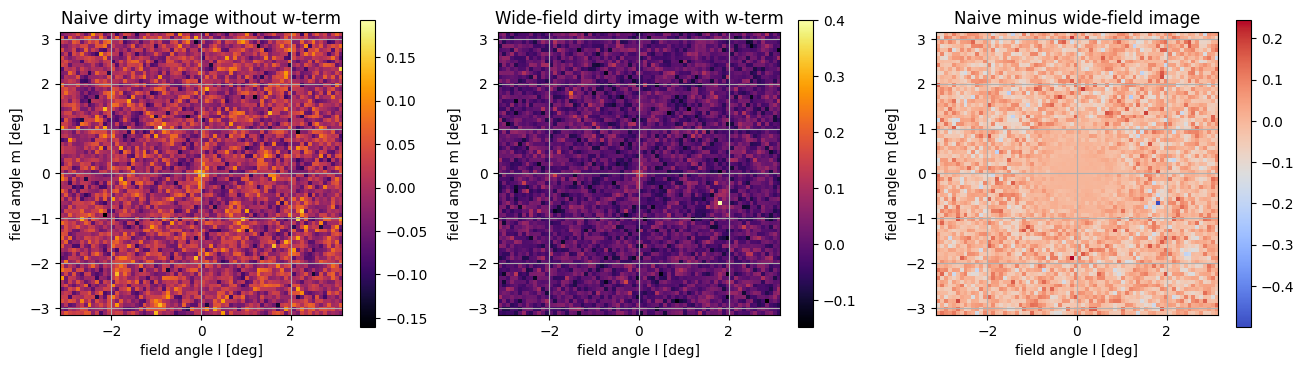

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.1))

for ax, image, title in [
    (axes[0], naive_dirty, "Naive dirty image without w-term"),
    (axes[1], widefield_dirty, "Wide-field dirty image with w-term"),
    (axes[2], wterm_error_map, "Naive minus wide-field image"),
]:
    cmap = "coolwarm" if title == "Naive minus wide-field image" else "inferno"
    im = ax.imshow(
        image,
        origin="lower",
        extent=extent_full_deg,
        cmap=cmap,
    )
    ax.set_title(title)
    ax.set_xlabel("field angle l [deg]")
    ax.set_ylabel("field angle m [deg]")
    plt.colorbar(im, ax=ax, shrink=0.82)

plt.tight_layout()

print(f"中心源峰值：忽略 w-term ≈ {center_peak_naive:.3f}，宽场校正后 ≈ {center_peak_wide:.3f}")
print(f"东侧离轴源峰值：忽略 w-term ≈ {east_peak_naive:.3f}，宽场校正后 ≈ {east_peak_wide:.3f}")
print(
    f"若忽略 w-term，东侧离轴源只恢复了宽场校正峰值的 "
    f"{100.0 * east_peak_naive / east_peak_wide:.1f}%"
)


这一步最重要的判断是：**宽场里的问题并不总能靠更深的 CLEAN 自动补回来。** 如果相位模型本身就少了 `w-term`，离轴结构的保真度会在成像前就已经受损。


### 9.12.2 faceting 为什么能在局部把离轴源救回来

faceting 的核心思想是：不要强迫整片天空都共享同一个相位中心，而是把感兴趣的宽场区域切成若干局部小块，在每个小块里重新定相和成像。

下面把相位中心移到东侧离轴源附近，只看一个小 facet。这个做法当然不是完整宽场算法，但它很适合作为 `w-projection` 和 faceting 思想的训练入口。


东侧离轴源在 naive 整场图中的局部峰值 ≈ 0.067
东侧离轴源在精确宽场图中的局部峰值 ≈ 0.400
东侧离轴源在 facet 图中的局部峰值 ≈ 0.483
facet 相比 naive 整场图，局部峰值提高了约 7.2 倍


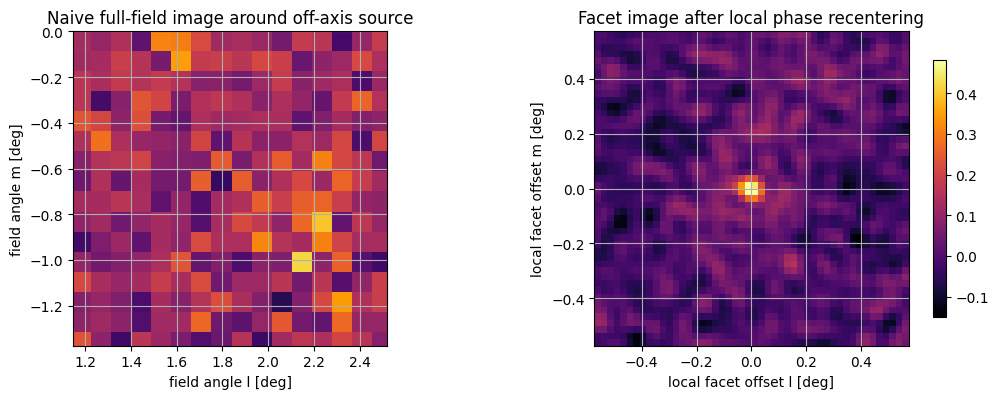

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.1))

east_window = [
    np.rad2deg(source_east["l"] - 0.012),
    np.rad2deg(source_east["l"] + 0.012),
    np.rad2deg(source_east["m"] - 0.012),
    np.rad2deg(source_east["m"] + 0.012),
]

axes[0].imshow(
    naive_dirty,
    origin="lower",
    extent=extent_full_deg,
    cmap="inferno",
)
axes[0].set_xlim(east_window[0], east_window[1])
axes[0].set_ylim(east_window[2], east_window[3])
axes[0].set_title("Naive full-field image around off-axis source")
axes[0].set_xlabel("field angle l [deg]")
axes[0].set_ylabel("field angle m [deg]")

im = axes[1].imshow(
    facet_dirty,
    origin="lower",
    extent=extent_facet_deg,
    cmap="inferno",
)
axes[1].set_title("Facet image after local phase recentering")
axes[1].set_xlabel("local facet offset l [deg]")
axes[1].set_ylabel("local facet offset m [deg]")
plt.colorbar(im, ax=axes[1], shrink=0.82)

plt.tight_layout()

print(f"东侧离轴源在 naive 整场图中的局部峰值 ≈ {east_peak_naive:.3f}")
print(f"东侧离轴源在精确宽场图中的局部峰值 ≈ {east_peak_wide:.3f}")
print(f"东侧离轴源在 facet 图中的局部峰值 ≈ {east_peak_facet:.3f}")
print(
    f"facet 相比 naive 整场图，局部峰值提高了约 "
    f"{east_peak_facet / east_peak_naive:.1f} 倍"
)


faceting 想传达的不是“最好永远手工切 facet”，而是一个更根本的宽场事实：**相位校正在宽场里本来就是方向依赖的。** 现代软件里的 `w-projection`、`w-stacking` 和更复杂的宽场算法，本质上都是在更系统地处理同一个问题。


### 9.12.3 多指向拼接为什么不能只做简单平均

`w-term` 处理的是宽场相位；主波束处理的是宽场增益。下面再做第二个实验：

- 构造两个相邻 pointing 的观测图；
- 先直接平均，得到 naive mosaic；
- 再按主波束权重做一个简化版的 `PB-aware mosaic`。

这样可以看到：简单平均会把边缘源压得很低，而 PB-aware 拼接可以把通量拉回来，但代价是边缘有效噪声上升。


科学区域内 naive mosaic 的平均绝对误差 ≈ 0.074
科学区域内 PB-aware mosaic 的平均绝对误差 ≈ 0.005
边缘源峰值：真实天空 ≈ 0.220，naive mosaic ≈ 0.025，PB-aware mosaic ≈ 0.209
边缘源位置的有效噪声约为中心重叠区的 5.3 倍


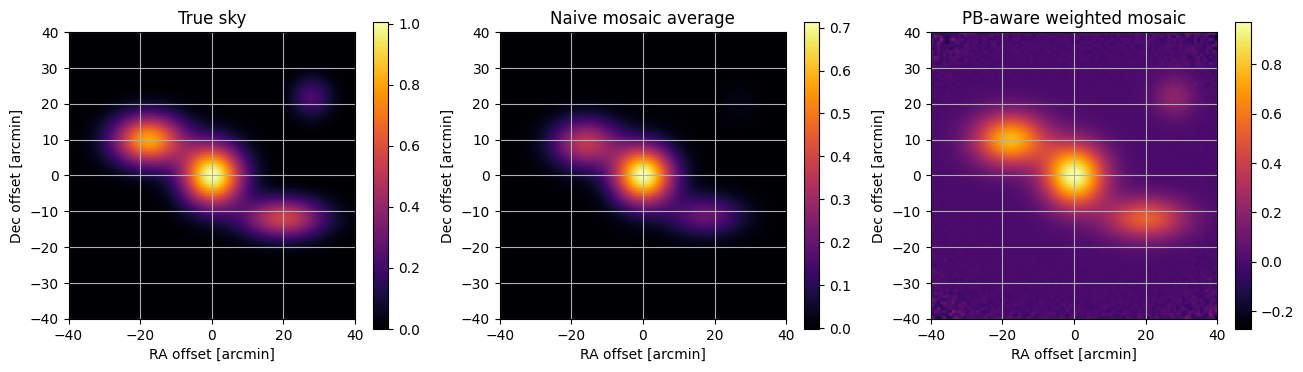

In [5]:
extent_arcmin = [
    mosaic_coords_arcmin[0],
    mosaic_coords_arcmin[-1],
    mosaic_coords_arcmin[0],
    mosaic_coords_arcmin[-1],
]

fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.1))

for ax, image, title in [
    (axes[0], mosaic_true_sky, "True sky"),
    (axes[1], naive_mosaic, "Naive mosaic average"),
    (axes[2], pb_weighted_mosaic, "PB-aware weighted mosaic"),
]:
    im = ax.imshow(
        image,
        origin="lower",
        extent=extent_arcmin,
        cmap="inferno",
    )
    ax.set_title(title)
    ax.set_xlabel("RA offset [arcmin]")
    ax.set_ylabel("Dec offset [arcmin]")
    plt.colorbar(im, ax=ax, shrink=0.82)

plt.tight_layout()

print(f"科学区域内 naive mosaic 的平均绝对误差 ≈ {mosaic_mean_abs_error_naive:.3f}")
print(
    f"科学区域内 PB-aware mosaic 的平均绝对误差 ≈ {mosaic_mean_abs_error_weighted:.3f}"
)
print(
    f"边缘源峰值：真实天空 ≈ {outer_peak_true:.3f}，"
    f"naive mosaic ≈ {outer_peak_naive:.3f}，"
    f"PB-aware mosaic ≈ {outer_peak_weighted:.3f}"
)
print(
    f"边缘源位置的有效噪声约为中心重叠区的 {mosaic_noise_ratio:.1f} 倍"
)


这里要建立的专业判断是：**主波束校正不是免费的。** 它能改善边缘通量恢复，但也会同步放大边缘噪声和建模误差。这正是为什么实际宽场数据处理中，mosaic 参数、PB cutoff 和科学分析半径必须一起设定。


### 9.12.4 与真实软件流程的对应

若把这两个教学实验映射回真实成像工作流，最常见的关键词大致包括：

- `w-projection`、`w-stacking`、faceting：处理非共面基线带来的 `w-term`；
- `A-projection`：在成像核里处理主波束等方向相关增益；
- `AW-projection`：把 `w-term` 和主波束方向相关效应一起放进成像算子；
- `mosaic`、`joint mosaic`：多指向宽场拼接与联合成像；
- 参数选择：`imsize`、`cell`、`gridder`、`wprojplanes`、`pb cutoff`、facet 数量和科学目标必须联动。

这个 notebook 想传达的最终结论是：**宽场方向相关成像不是单一按钮，而是相位项、主波束项和拼接策略共同决定的工作流。** 如果科学目标在大视场边缘、或者动态范围很高，那么这些问题都不能交给默认值处理。
